# Análisis Exploratorio del Dataset

In [10]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from collections import defaultdict
from tqdm.auto import tqdm

FRAMES_PATH = Path('/Users/sofiaramos/Desktop/DEEPFAKES/frames')
CSV_PATH    = Path('/Users/sofiaramos/Desktop/DEEPFAKES/FaceForensics++_C23/csv')

CLASSES = ['real', 'Deepfakes', 'Face2Face', 'FaceShifter', 'FaceSwap', 'NeuralTextures', 'DeepFakeDetection']
COLORS  = ["#aacc96", '#25533f', '#52a5ce', '#ff7bac', '#6d1f42', '#d3b6d3', '#ef6f3c']

## 1. Distribución del dataset

In [11]:
counts = {}
for cls in CLASSES:
    cls_path = FRAMES_PATH / cls
    if cls_path.exists():
        n = sum(1 for _ in cls_path.rglob('*.jpg'))
        counts[cls] = n
    else:
        counts[cls] = 0

df_counts = pd.DataFrame(list(counts.items()), columns=['Clase', 'Frames'])
df_counts['Tipo'] = df_counts['Clase'].apply(lambda x: 'Real' if x == 'real' else 'Deepfake')
df_counts['Porcentaje'] = (df_counts['Frames'] / df_counts['Frames'].sum() * 100).round(1)

print(df_counts.to_string(index=False))
print(f"\nTotal frames: {df_counts['Frames'].sum():,}")
print(f"Total reales: {df_counts[df_counts['Tipo']=='Real']['Frames'].sum():,}")
print(f"Total deepfakes: {df_counts[df_counts['Tipo']=='Deepfake']['Frames'].sum():,}")

            Clase  Frames     Tipo  Porcentaje
             real   10000     Real        14.3
        Deepfakes   10000 Deepfake        14.3
        Face2Face   10000 Deepfake        14.3
      FaceShifter   10000 Deepfake        14.3
         FaceSwap   10000 Deepfake        14.3
   NeuralTextures   10000 Deepfake        14.3
DeepFakeDetection    9995 Deepfake        14.3

Total frames: 69,995
Total reales: 10,000
Total deepfakes: 59,995


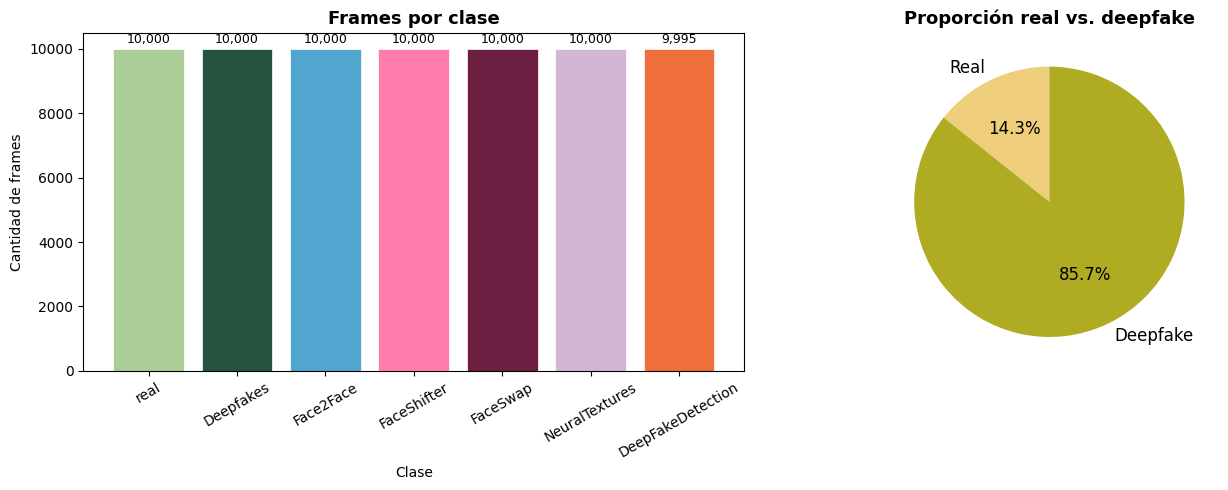

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars = ax1.bar(df_counts['Clase'], df_counts['Frames'], color=COLORS, edgecolor='white', linewidth=0.5)
ax1.set_title('Frames por clase', fontsize=13, fontweight='bold')
ax1.set_xlabel('Clase')
ax1.set_ylabel('Cantidad de frames')
ax1.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, df_counts['Frames']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:,}', ha='center', va='bottom', fontsize=9)

real_total = df_counts[df_counts['Tipo']=='Real']['Frames'].sum()
fake_total = df_counts[df_counts['Tipo']=='Deepfake']['Frames'].sum()
ax2.pie([real_total, fake_total], labels=['Real', 'Deepfake'],
        colors=['#efce7b', '#afab23'], autopct='%1.1f%%',
        startangle=90, textprops={'fontsize': 12})
ax2.set_title('Proporción real vs. deepfake', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 2. Ejemplos visuales por clase

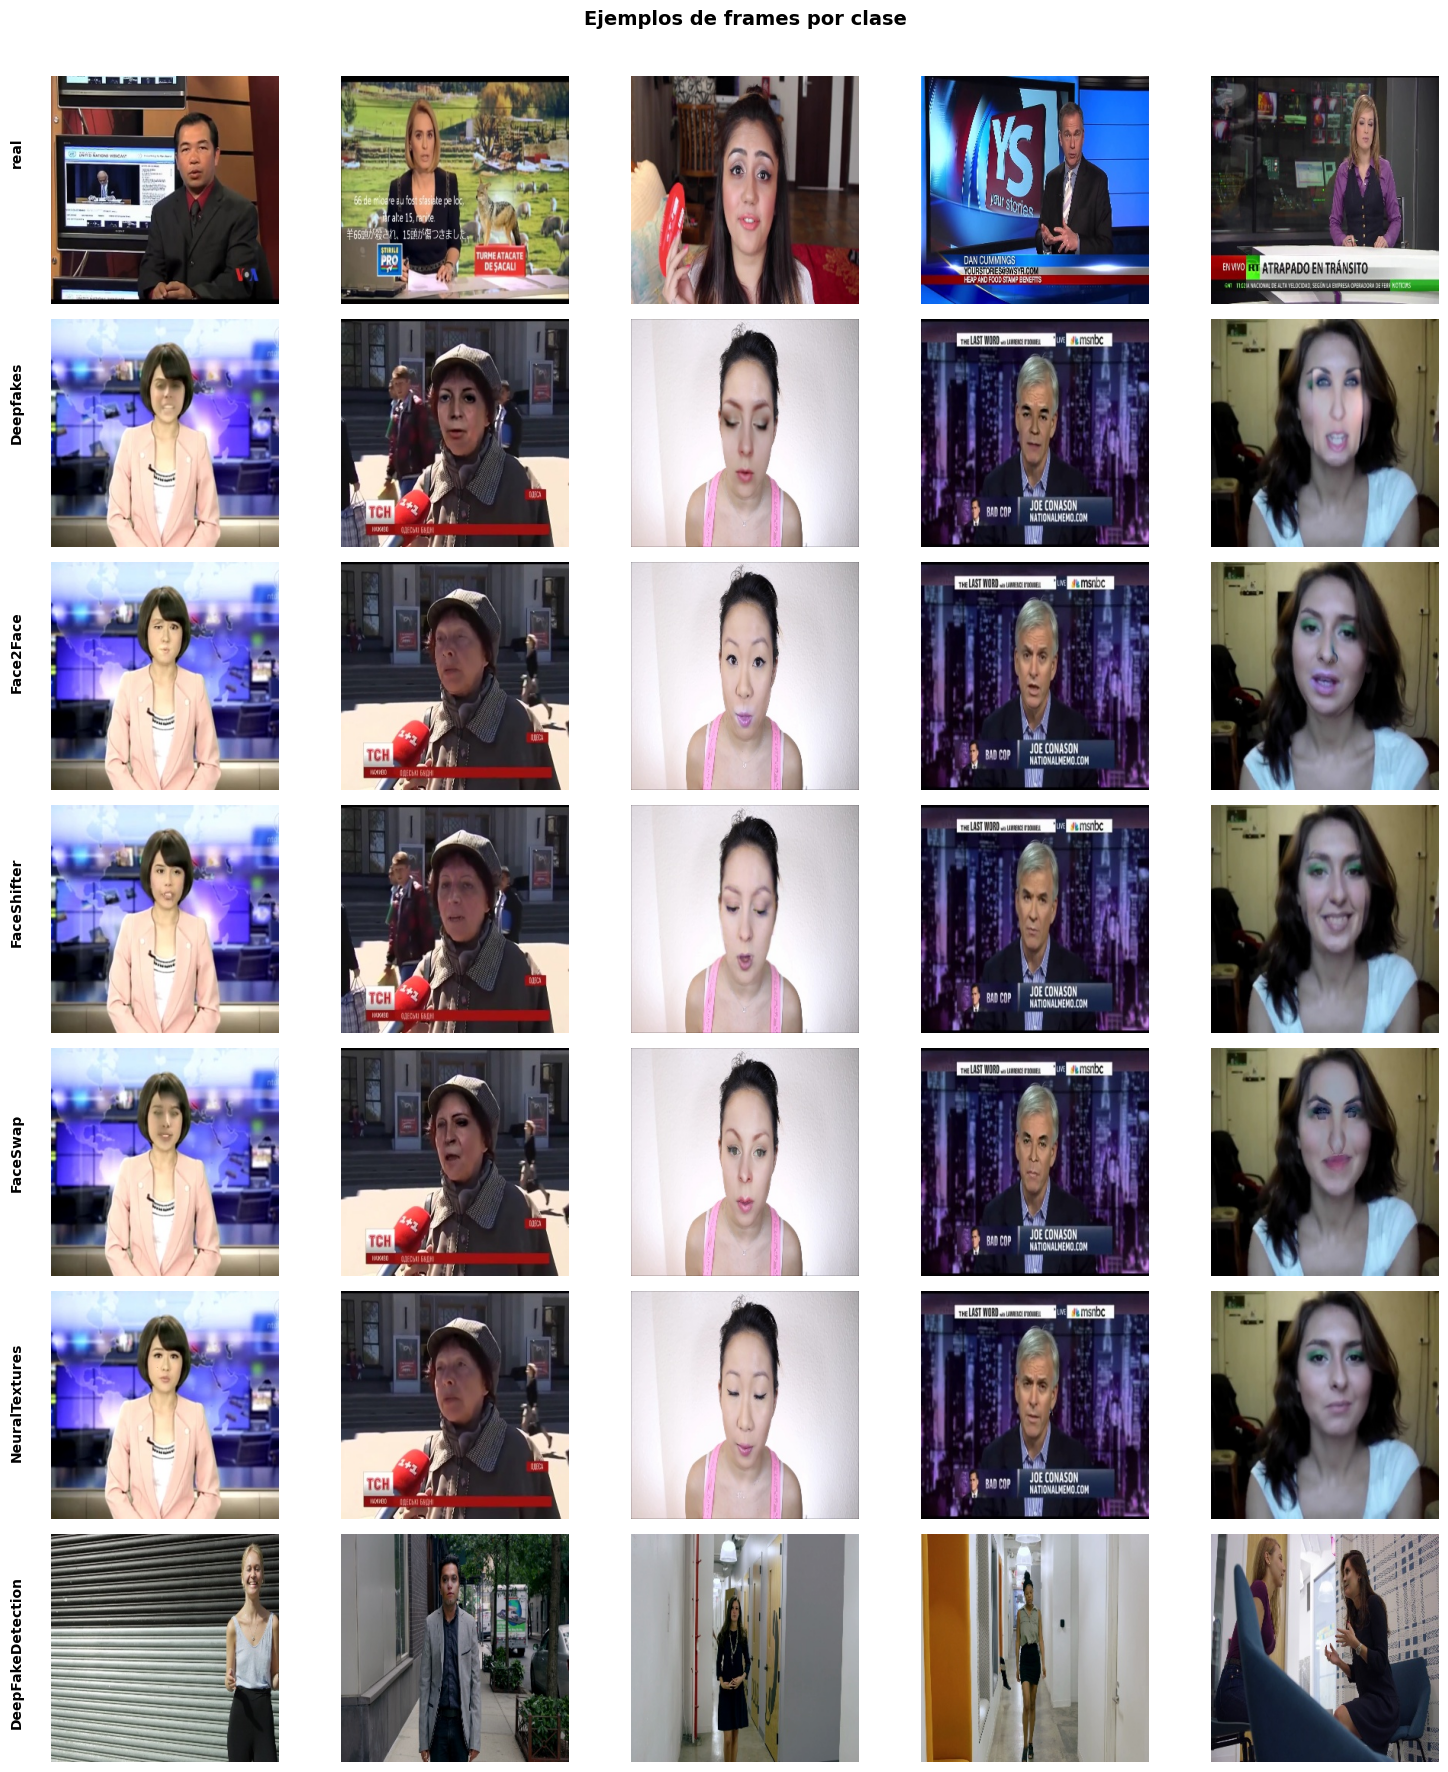

In [13]:
def get_sample_frames(cls, n=5):
    """Obtiene n frames de muestra de una clase."""
    cls_path = FRAMES_PATH / cls
    all_frames = list(cls_path.rglob('*.jpg'))
    if len(all_frames) == 0:
        return []
    indices = np.linspace(0, len(all_frames)-1, n, dtype=int)
    return [all_frames[i] for i in indices]

fig, axes = plt.subplots(len(CLASSES), 5, figsize=(15, len(CLASSES)*2.5))
fig.suptitle('Ejemplos de frames por clase', fontsize=14, fontweight='bold', y=1.01)

for row, cls in enumerate(CLASSES):
    samples = get_sample_frames(cls, n=5)
    for col in range(5):
        ax = axes[row, col]
        if col < len(samples):
            img = cv2.imread(str(samples[col]))
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                ax.imshow(img)
            else:
                try:
                    img = plt.imread(str(samples[col]))
                    ax.imshow(img)
                except Exception:
                    ax.text(0.5, 0.5, 'No image', ha='center', va='center', fontsize=8, color='#999999')
        else:
            ax.text(0.5, 0.5, 'No image', ha='center', va='center', fontsize=8, color='#999999')
        ax.axis('off')
    y = 1 - (row + 0.5) / len(CLASSES)
    fig.text(0.01, y, cls, fontsize=10, fontweight='bold', color='black', va='center', rotation=90)

plt.tight_layout()
plt.show()

Ya a ojo se puede ver que los deepfakes de algunas clases tienen artefactos visibles.

## 3. Análisis de calidad de imágenes

In [14]:
SAMPLE_SIZE = 100

stats = defaultdict(lambda: {'brightness': [], 'contrast': [], 'sharpness': []})

for cls in tqdm(CLASSES, desc='Analizando clases'):
    cls_path = FRAMES_PATH / cls
    all_frames = list(cls_path.rglob('*.jpg'))
    sample = np.random.choice(all_frames, min(SAMPLE_SIZE, len(all_frames)), replace=False)

    for fp in sample:
        img = cv2.imread(str(fp), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        stats[cls]['brightness'].append(float(np.mean(img)))
        stats[cls]['contrast'].append(float(np.std(img)))
        # Nitidez: varianza del laplaciano (mayor = más nítido)
        lap = cv2.Laplacian(img, cv2.CV_64F)
        stats[cls]['sharpness'].append(float(lap.var()))

Analizando clases: 100%|██████████| 7/7 [00:01<00:00,  6.61it/s]


In [15]:
rows = []
for cls in CLASSES:
    rows.append({
        'Clase': cls,
        'Brightness (media)': round(np.mean(stats[cls]['brightness']), 2),
        'Contraste (std)':    round(np.mean(stats[cls]['contrast']), 2),
        'Nitidez (var lap)':  round(np.mean(stats[cls]['sharpness']), 2),
    })
df_stats = pd.DataFrame(rows)
print(df_stats.to_string(index=False))

            Clase  Brightness (media)  Contraste (std)  Nitidez (var lap)
             real               99.92            59.49            1838.25
        Deepfakes              103.46            59.76            1650.53
        Face2Face              104.98            58.79            1763.70
      FaceShifter              100.96            59.33            1987.35
         FaceSwap              101.47            57.74            1952.32
   NeuralTextures               96.82            57.61            1439.87
DeepFakeDetection              117.22            58.75            1416.31


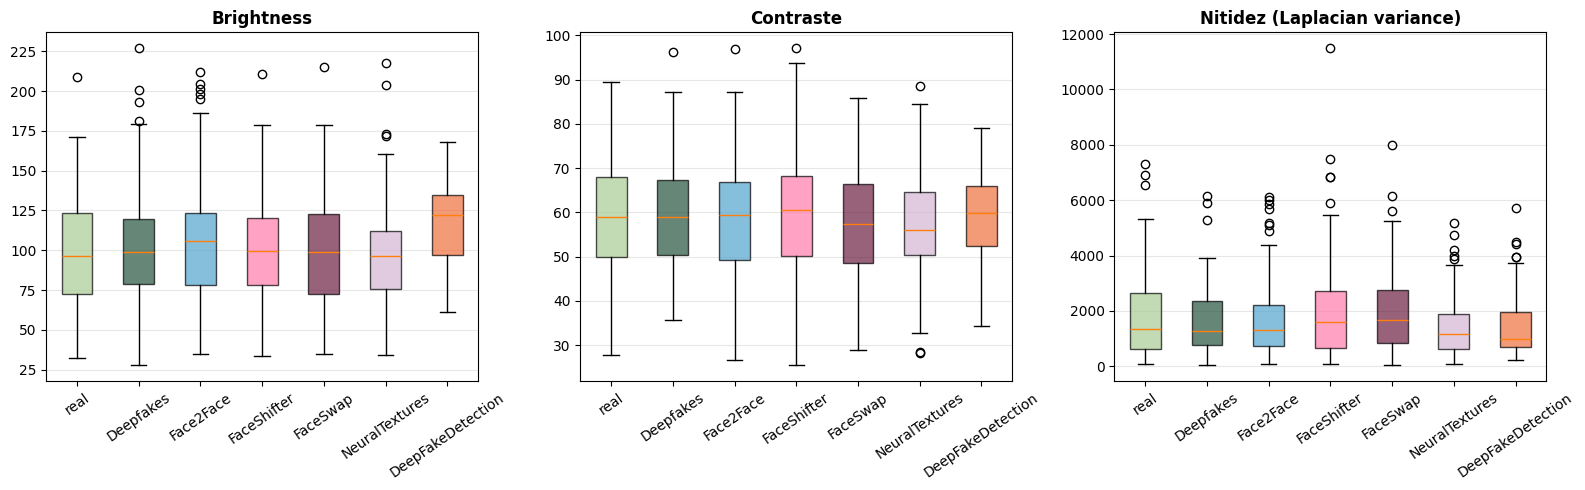

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['brightness', 'contrast', 'sharpness']
titles  = ['Brightness', 'Contraste', 'Nitidez (Laplacian variance)']

for ax, metric, title in zip(axes, metrics, titles):
    data   = [stats[cls][metric] for cls in CLASSES]
    bp = ax.boxplot(data, tick_labels=CLASSES, patch_artist=True)
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=35)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Análisis de los CSVs de metadata

In [17]:
csv_files = list(CSV_PATH.glob('*.csv')) if CSV_PATH.exists() else []
print(f'CSVs encontrados: {len(csv_files)}')
for f in csv_files:
    print(f'  {f.name}')

CSVs encontrados: 10
  NeuralTextures.csv
  Deepfakes.csv
  DeepFakeDetection.csv
  Mean_Data.csv
  FF++_Metadata.csv
  original.csv
  FaceSwap.csv
  FaceShifter.csv
  FF++_Metadata_Shuffled.csv
  Face2Face.csv


In [18]:
dfs = {}
for csv_file in csv_files:
    try:
        df = pd.read_csv(csv_file)
        dfs[csv_file.name] = df
        print(f'\n── {csv_file.name} ──')
        print(f'  Filas: {len(df)} | Columnas: {list(df.columns)}')
        print(df.head(3).to_string())
    except Exception as e:
        print(f'  Error leyendo {csv_file.name}: {e}')


── NeuralTextures.csv ──
  Filas: 1000 | Columnas: ['Unnamed: 0', 'File Path', 'Label', 'Frame Count', 'Width', 'Height', 'Codec', 'File Size(MB)']
   Unnamed: 0                   File Path Label  Frame Count  Width  Height Codec  File Size(MB)
0           0  NeuralTextures/000_003.mp4  FAKE          303    640     480  h264           0.62
1           1  NeuralTextures/001_870.mp4  FAKE          460   1280     720  h264           2.71
2           2  NeuralTextures/002_006.mp4  FAKE          310   1280     720  h264           0.91

── Deepfakes.csv ──
  Filas: 1000 | Columnas: ['Unnamed: 0', 'File Path', 'Label', 'Frame Count', 'Width', 'Height', 'Codec', 'File Size(MB)']
   Unnamed: 0              File Path Label  Frame Count  Width  Height Codec  File Size(MB)
0           0  Deepfakes/000_003.mp4  FAKE          396    640     480  h264           0.85
1           1  Deepfakes/001_870.mp4  FAKE          460   1280     720  h264           2.74
2           2  Deepfakes/002_006.mp4  FAKE 

Tienen metadata útil: ruta del video, label REAL/FAKE, cantidad de frames, resolución, codec y tamaño. Lo más valioso es que FF++_Metadata_Shuffled.csv tiene los 7000 videos mezclados, se puede usar directamente para hacer el split train/val/test por video en lugar de por frame para evitar data leakage.